In [ ]:
# 1. Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Unzip the Dataset (Quietly)
import zipfile
import os

zip_path = '/content/drive/MyDrive/FYP_Project/Mini_Dataset.zip'
extract_path = '/content/dataset'

if not os.path.exists(extract_path):
    print("📂 Unzipping dataset... (This takes 10-20 seconds)")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✅ Unzipped successfully!")
else:
    print("✅ Dataset already exists. Skipping unzip.")

train_dir = os.path.join(extract_path, '03_Mini_Dataset', 'Train')
val_dir = os.path.join(extract_path, '03_Mini_Dataset', 'Val')

print(f"Train Path: {train_dir}")
print(f"Images in Real Train: {len(os.listdir(os.path.join(train_dir, 'Real')))}")

Mounted at /content/drive
📂 Unzipping dataset... (This takes 10-20 seconds)
✅ Unzipped successfully!
Train Path: /content/dataset/03_Mini_Dataset/Train
Images in Real Train: 4149


🚀 Starting ViT_B_16 - Run_01_ConfigA on cuda...
📊 Dataset Stats: Train=8298, Val=1600
⏳ Loading ViT_B_16 weights...
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 119MB/s]



Epoch 1/50
----------
Train Loss: 0.3011 Acc: 0.8544
Val Loss: 0.0075 Acc: 0.9981
   📊 Precision: 1.0000 | Recall: 0.9962 | Spec: 1.0000 | AUC: 1.0000

Epoch 2/50
----------
Train Loss: 0.1369 Acc: 0.9431
Val Loss: 0.0148 Acc: 0.9956
   📊 Precision: 1.0000 | Recall: 0.9912 | Spec: 1.0000 | AUC: 1.0000

Epoch 3/50
----------
Train Loss: 0.1261 Acc: 0.9470
Val Loss: 0.0119 Acc: 0.9969
   📊 Precision: 1.0000 | Recall: 0.9938 | Spec: 1.0000 | AUC: 1.0000

Epoch 4/50
----------
Train Loss: 0.1087 Acc: 0.9555
Val Loss: 0.0023 Acc: 0.9988
   📊 Precision: 0.9988 | Recall: 0.9988 | Spec: 0.9988 | AUC: 1.0000

Epoch 5/50
----------
Train Loss: 0.0879 Acc: 0.9630
Val Loss: 0.0088 Acc: 0.9962
   📊 Precision: 1.0000 | Recall: 0.9925 | Spec: 1.0000 | AUC: 1.0000

Epoch 6/50
----------
Train Loss: 0.0912 Acc: 0.9622
Val Loss: 0.0258 Acc: 0.9906
   📊 Precision: 0.9987 | Recall: 0.9825 | Spec: 0.9988 | AUC: 1.0000

Epoch 7/50
----------
Train Loss: 0.0790 Acc: 0.9683
Val Loss: 0.0216 Acc: 0.9931
   📊 

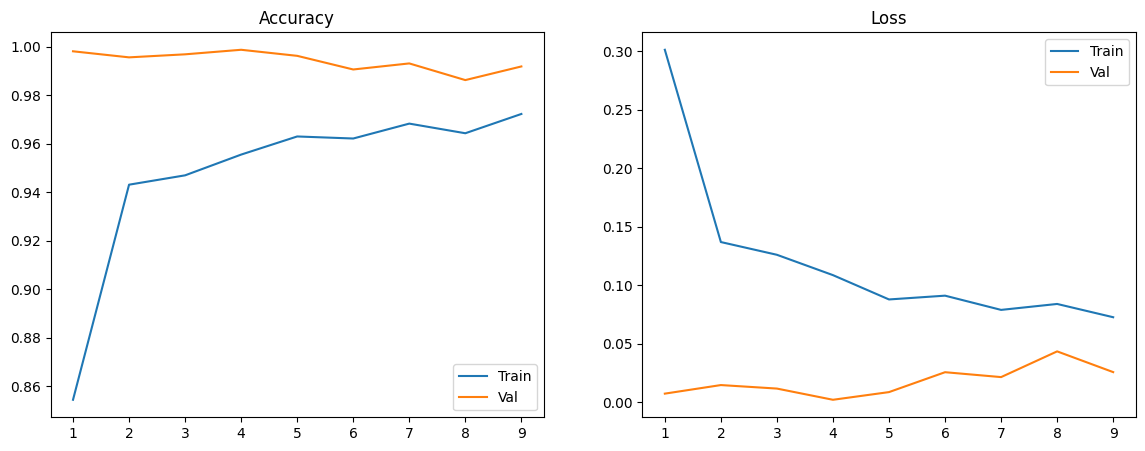

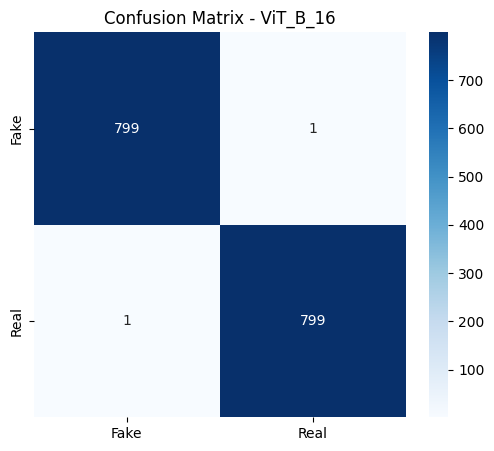

✅ ViT Config A - Done.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import time
import os
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURATION (ViT - CONFIG A) ---
RUN_NAME       = "Run_01_ConfigA"
MODEL_ARCH     = "ViT_B_16"        
BATCH_SIZE     = 16                
LEARNING_RATE  = 0.0001            # 1e-4
OPTIMIZER_NAME = "Adam"
NUM_EPOCHS     = 50                # ViT converges faster
PATIENCE       = 5

SAVE_DIR = f"/content/drive/MyDrive/FYP_Project/Models/{MODEL_ARCH}"
os.makedirs(SAVE_DIR, exist_ok=True)

# --- 2. SETUP DATA & MODEL ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Starting {MODEL_ARCH} - {RUN_NAME} on {device}...")

# USING THE "NUCLEAR" AUGMENTATIONS
data_transforms = {
    'Train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2)),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        transforms.RandomGrayscale(p=0.1),
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'Val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/dataset/03_Mini_Dataset'

if os.path.exists(data_dir):
    image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['Train', 'Val']}
    dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=True, num_workers=2) for x in ['Train', 'Val']}
    dataset_sizes = {x: len(image_datasets[x]) for x in ['Train', 'Val']}
    print(f"📊 Dataset Stats: Train={dataset_sizes['Train']}, Val={dataset_sizes['Val']}")
else:
    print("❌ ERROR: Dataset not found.")
    exit()

# --- LOAD VISION TRANSFORMER (ViT) ---
print(f"⏳ Loading {MODEL_ARCH} weights...")
model = models.vit_b_16(weights='DEFAULT')

# ViT Head Replacement
# The classifier in ViT is called 'heads', and the layer is 'head'
num_ftrs = model.heads.head.in_features
model.heads.head = nn.Linear(num_ftrs, 2)
model = model.to(device)

# --- HYPERPARAMETER SWITCH ---
if OPTIMIZER_NAME == "Adam":
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
elif OPTIMIZER_NAME == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)

criterion = nn.CrossEntropyLoss()

# --- 3. TRAINING LOOP ---
since = time.time()
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
early_stop_counter = 0
history = []

for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 10)
    epoch_stats = {'Epoch': epoch+1}

    for phase in ['Train', 'Val']:
        if phase == 'Train': model.train()
        else: model.eval()

        running_loss = 0.0
        running_corrects = 0
        all_labels = []
        all_preds = []
        all_probs_fake = []

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'Train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                if phase == 'Train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            if phase == 'Val':
                probs = torch.nn.functional.softmax(outputs, dim=1)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs_fake.extend(probs[:, 0].cpu().detach().numpy())

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        epoch_stats[f'{phase}_Loss'] = epoch_loss
        epoch_stats[f'{phase}_Acc'] = epoch_acc.item()

        if phase == 'Val':
            binary_labels = [1 if x == 0 else 0 for x in all_labels]
            binary_preds  = [1 if x == 0 else 0 for x in all_preds]

            prec = precision_score(binary_labels, binary_preds, zero_division=0)
            rec  = recall_score(binary_labels, binary_preds, zero_division=0)
            f1   = f1_score(binary_labels, binary_preds, zero_division=0)
            try: auc = roc_auc_score(binary_labels, all_probs_fake)
            except: auc = 0.5
            tn, fp, fn, tp = confusion_matrix(binary_labels, binary_preds).ravel()
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

            print(f"   📊 Precision: {prec:.4f} | Recall: {rec:.4f} | Spec: {specificity:.4f} | AUC: {auc:.4f}")

            epoch_stats['Precision'] = prec
            epoch_stats['Recall'] = rec
            epoch_stats['Specificity'] = specificity
            epoch_stats['F1'] = f1
            epoch_stats['AUC'] = auc

            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                early_stop_counter = 0
            else:
                early_stop_counter += 1

    history.append(epoch_stats)
    if early_stop_counter >= PATIENCE:
        print(f"\n⏹️ Early stopping at epoch {epoch+1}")
        break

# Save & Plot
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_model.pth"))
pd.DataFrame(history).to_csv(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_metrics.csv"), index=False)

df = pd.DataFrame(history)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1); plt.plot(df['Epoch'], df['Train_Acc'], label='Train'); plt.plot(df['Epoch'], df['Val_Acc'], label='Val'); plt.title('Accuracy'); plt.legend()
plt.subplot(1, 2, 2); plt.plot(df['Epoch'], df['Train_Loss'], label='Train'); plt.plot(df['Epoch'], df['Val_Loss'], label='Val'); plt.title('Loss'); plt.legend()
plt.savefig(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_plots.png"))

# CM
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in dataloaders['Val']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title(f'Confusion Matrix - {MODEL_ARCH}')
plt.savefig(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_conf_matrix.png"))
plt.show()

print("✅ ViT Config A - Done.")

📂 Saving results to: /content/drive/MyDrive/FYP_Project/Models/ViT_B_16/Run_02_ConfigB_Batch32
🚀 Starting ViT_B_16 - Run_02_ConfigB_Batch32 on cuda...
📊 Dataset Stats: Train=8298, Val=1600
⏳ Loading ViT_B_16 weights...

Epoch 1/50
----------
Train Loss: 0.3217 Acc: 0.8418
Val Loss: 0.0615 Acc: 0.9794
   📊 Precision: 0.9974 | Recall: 0.9613 | Spec: 0.9975 | AUC: 0.9998

Epoch 2/50
----------
Train Loss: 0.1251 Acc: 0.9491
Val Loss: 0.1169 Acc: 0.9525
   📊 Precision: 1.0000 | Recall: 0.9050 | Spec: 1.0000 | AUC: 0.9999

Epoch 3/50
----------
Train Loss: 0.0899 Acc: 0.9669
Val Loss: 0.0186 Acc: 0.9950
   📊 Precision: 1.0000 | Recall: 0.9900 | Spec: 1.0000 | AUC: 1.0000

Epoch 4/50
----------
Train Loss: 0.0730 Acc: 0.9713
Val Loss: 0.0710 Acc: 0.9769
   📊 Precision: 1.0000 | Recall: 0.9537 | Spec: 1.0000 | AUC: 1.0000

Epoch 5/50
----------
Train Loss: 0.0704 Acc: 0.9719
Val Loss: 0.0151 Acc: 0.9938
   📊 Precision: 1.0000 | Recall: 0.9875 | Spec: 1.0000 | AUC: 1.0000

Epoch 6/50
---------

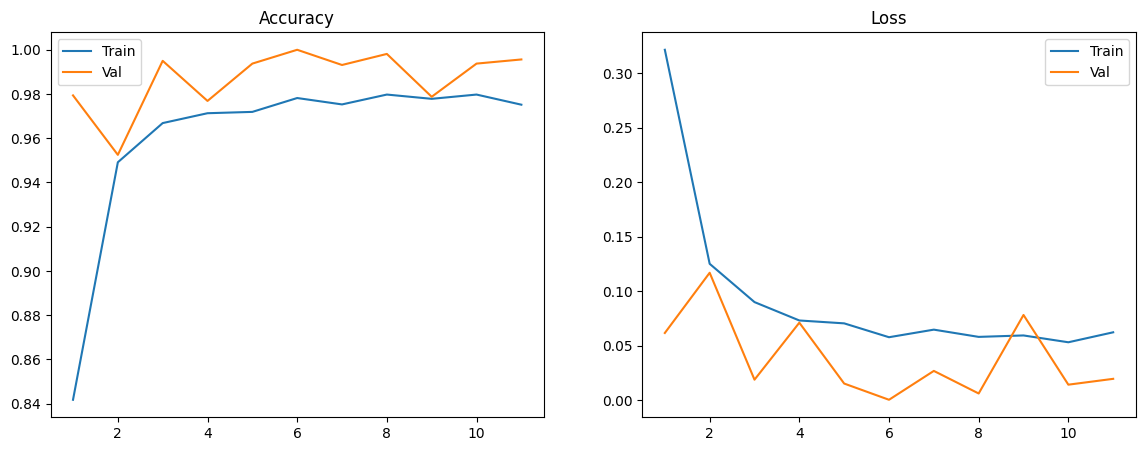

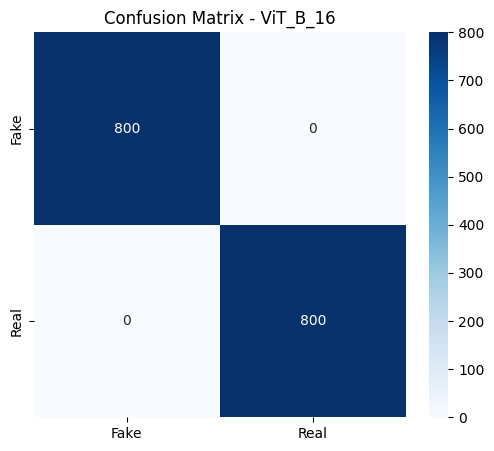

✅ ViT Config B (Batch 32) - Done.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import time
import os
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURATION (ViT - CONFIG B - BATCH 32) ---
RUN_NAME       = "Run_02_ConfigB_Batch32"  # <--- CONFIG B
MODEL_ARCH     = "ViT_B_16"                # ViT
BATCH_SIZE     = 32                        # <--- CHANGED TO 32 (Watch VRAM!)
LEARNING_RATE  = 0.0001
OPTIMIZER_NAME = "Adam"
NUM_EPOCHS     = 50
PATIENCE       = 5

SAVE_DIR = f"/content/drive/MyDrive/FYP_Project/Models/{MODEL_ARCH}/{RUN_NAME}"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"📂 Saving results to: {SAVE_DIR}")

# --- 2. SETUP DATA & MODEL ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Starting {MODEL_ARCH} - {RUN_NAME} on {device}...")

# USING THE "NUCLEAR" AUGMENTATIONS
data_transforms = {
    'Train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2)),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        transforms.RandomGrayscale(p=0.1),
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'Val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/dataset/03_Mini_Dataset'

if os.path.exists(data_dir):
    image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['Train', 'Val']}
    dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=True, num_workers=2) for x in ['Train', 'Val']}
    dataset_sizes = {x: len(image_datasets[x]) for x in ['Train', 'Val']}
    print(f"📊 Dataset Stats: Train={dataset_sizes['Train']}, Val={dataset_sizes['Val']}")
else:
    print("❌ ERROR: Dataset not found.")
    exit()

# --- LOAD ViT ---
print(f"⏳ Loading {MODEL_ARCH} weights...")
model = models.vit_b_16(weights='DEFAULT')

# ViT Head Replacement
num_ftrs = model.heads.head.in_features
model.heads.head = nn.Linear(num_ftrs, 2)
model = model.to(device)

if OPTIMIZER_NAME == "Adam":
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
elif OPTIMIZER_NAME == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)

criterion = nn.CrossEntropyLoss()

# --- 3. TRAINING LOOP ---
since = time.time()
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
early_stop_counter = 0
history = []

for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 10)
    epoch_stats = {'Epoch': epoch+1}

    for phase in ['Train', 'Val']:
        if phase == 'Train': model.train()
        else: model.eval()

        running_loss = 0.0
        running_corrects = 0
        all_labels = []
        all_preds = []
        all_probs_fake = []

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'Train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                if phase == 'Train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            if phase == 'Val':
                probs = torch.nn.functional.softmax(outputs, dim=1)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs_fake.extend(probs[:, 0].cpu().detach().numpy())

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        epoch_stats[f'{phase}_Loss'] = epoch_loss
        epoch_stats[f'{phase}_Acc'] = epoch_acc.item()

        if phase == 'Val':
            binary_labels = [1 if x == 0 else 0 for x in all_labels]
            binary_preds  = [1 if x == 0 else 0 for x in all_preds]

            prec = precision_score(binary_labels, binary_preds, zero_division=0)
            rec  = recall_score(binary_labels, binary_preds, zero_division=0)
            f1   = f1_score(binary_labels, binary_preds, zero_division=0)
            try: auc = roc_auc_score(binary_labels, all_probs_fake)
            except: auc = 0.5
            tn, fp, fn, tp = confusion_matrix(binary_labels, binary_preds).ravel()
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

            print(f"   📊 Precision: {prec:.4f} | Recall: {rec:.4f} | Spec: {specificity:.4f} | AUC: {auc:.4f}")

            epoch_stats['Precision'] = prec
            epoch_stats['Recall'] = rec
            epoch_stats['Specificity'] = specificity
            epoch_stats['F1'] = f1
            epoch_stats['AUC'] = auc

            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                early_stop_counter = 0
            else:
                early_stop_counter += 1

    history.append(epoch_stats)
    if early_stop_counter >= PATIENCE:
        print(f"\n⏹️ Early stopping at epoch {epoch+1}")
        break

# Save & Plot
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_model.pth"))
pd.DataFrame(history).to_csv(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_metrics.csv"), index=False)

df = pd.DataFrame(history)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1); plt.plot(df['Epoch'], df['Train_Acc'], label='Train'); plt.plot(df['Epoch'], df['Val_Acc'], label='Val'); plt.title('Accuracy'); plt.legend()
plt.subplot(1, 2, 2); plt.plot(df['Epoch'], df['Train_Loss'], label='Train'); plt.plot(df['Epoch'], df['Val_Loss'], label='Val'); plt.title('Loss'); plt.legend()
plt.savefig(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_plots.png"))

# CM
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in dataloaders['Val']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title(f'Confusion Matrix - {MODEL_ARCH}')
plt.savefig(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_conf_matrix.png"))
plt.show()

print("✅ ViT Config B (Batch 32) - Done.")

📂 Saving results to: /content/drive/MyDrive/FYP_Project/Models/ViT_B_16/Run_03_ConfigC_SGD
🚀 Starting ViT_B_16 - Run_03_ConfigC_SGD on cuda...
📊 Dataset Stats: Train=8298, Val=1600
⏳ Loading ViT_B_16 weights...
⚙️ Using SGD Optimizer (Momentum=0.9)

Epoch 1/50
----------
Train Loss: 0.2617 Acc: 0.8779
Val Loss: 0.2906 Acc: 0.8944
   📊 Precision: 0.9984 | Recall: 0.7900 | Spec: 0.9988 | AUC: 0.9989

Epoch 2/50
----------
Train Loss: 0.1378 Acc: 0.9442
Val Loss: 0.0119 Acc: 0.9956
   📊 Precision: 0.9975 | Recall: 0.9938 | Spec: 0.9975 | AUC: 0.9999

Epoch 3/50
----------
Train Loss: 0.1081 Acc: 0.9529
Val Loss: 0.0420 Acc: 0.9881
   📊 Precision: 1.0000 | Recall: 0.9762 | Spec: 1.0000 | AUC: 0.9999

Epoch 4/50
----------
Train Loss: 0.0771 Acc: 0.9679
Val Loss: 0.0113 Acc: 0.9962
   📊 Precision: 0.9987 | Recall: 0.9938 | Spec: 0.9988 | AUC: 1.0000

Epoch 5/50
----------
Train Loss: 0.0676 Acc: 0.9718
Val Loss: 0.0330 Acc: 0.9913
   📊 Precision: 0.9987 | Recall: 0.9838 | Spec: 0.9988 | AUC

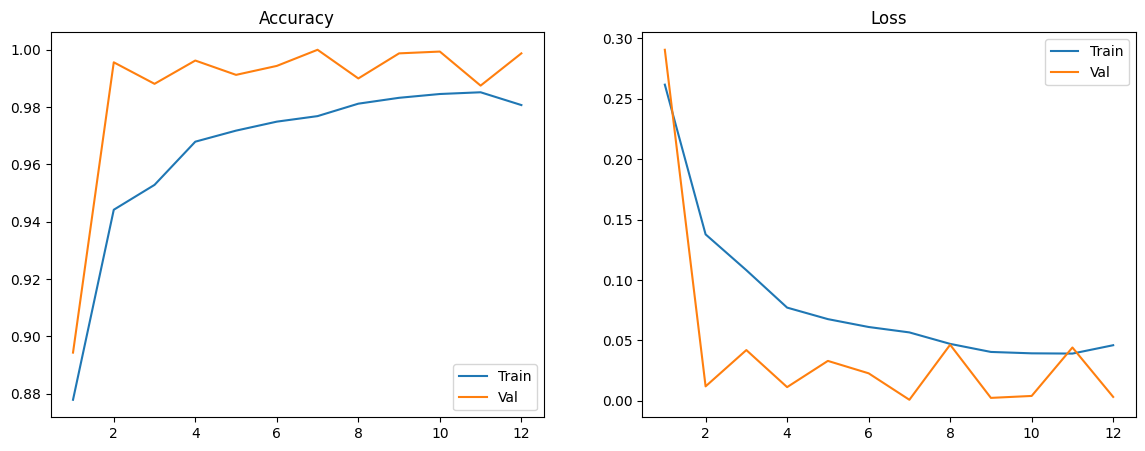

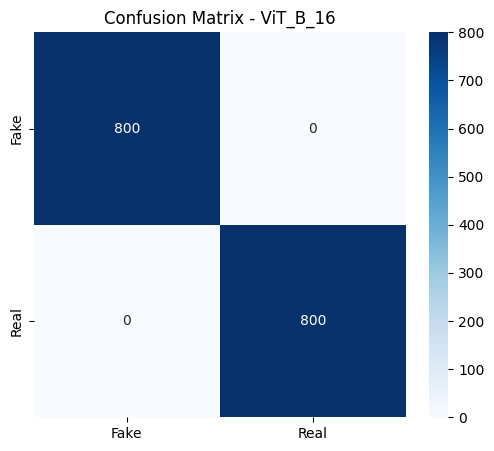

✅ ViT Config C (SGD) - Done.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import time
import os
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURATION (ViT - CONFIG C - SGD) ---
RUN_NAME       = "Run_03_ConfigC_SGD"      # <--- CONFIG C
MODEL_ARCH     = "ViT_B_16"                # ViT
BATCH_SIZE     = 16                        # Back to 16
LEARNING_RATE  = 0.001                     # <--- SGD Needs Higher LR
OPTIMIZER_NAME = "SGD"                     # <--- SWITCH TO SGD
NUM_EPOCHS     = 50
PATIENCE       = 5

SAVE_DIR = f"/content/drive/MyDrive/FYP_Project/Models/{MODEL_ARCH}/{RUN_NAME}"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"📂 Saving results to: {SAVE_DIR}")

# --- 2. SETUP DATA & MODEL ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Starting {MODEL_ARCH} - {RUN_NAME} on {device}...")

# USING THE "NUCLEAR" AUGMENTATIONS
data_transforms = {
    'Train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2)),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        transforms.RandomGrayscale(p=0.1),
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'Val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/dataset/03_Mini_Dataset'

if os.path.exists(data_dir):
    image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['Train', 'Val']}
    dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=True, num_workers=2) for x in ['Train', 'Val']}
    dataset_sizes = {x: len(image_datasets[x]) for x in ['Train', 'Val']}
    print(f"📊 Dataset Stats: Train={dataset_sizes['Train']}, Val={dataset_sizes['Val']}")
else:
    print("❌ ERROR: Dataset not found.")
    exit()

# --- LOAD ViT ---
print(f"⏳ Loading {MODEL_ARCH} weights...")
model = models.vit_b_16(weights='DEFAULT')

# ViT Head Replacement
num_ftrs = model.heads.head.in_features
model.heads.head = nn.Linear(num_ftrs, 2)
model = model.to(device)

if OPTIMIZER_NAME == "Adam":
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
elif OPTIMIZER_NAME == "SGD":
    print("⚙️ Using SGD Optimizer (Momentum=0.9)")
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)

criterion = nn.CrossEntropyLoss()

# --- 3. TRAINING LOOP ---
since = time.time()
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
early_stop_counter = 0
history = []

for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 10)
    epoch_stats = {'Epoch': epoch+1}

    for phase in ['Train', 'Val']:
        if phase == 'Train': model.train()
        else: model.eval()

        running_loss = 0.0
        running_corrects = 0
        all_labels = []
        all_preds = []
        all_probs_fake = []

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'Train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                if phase == 'Train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            if phase == 'Val':
                probs = torch.nn.functional.softmax(outputs, dim=1)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs_fake.extend(probs[:, 0].cpu().detach().numpy())

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        epoch_stats[f'{phase}_Loss'] = epoch_loss
        epoch_stats[f'{phase}_Acc'] = epoch_acc.item()

        if phase == 'Val':
            binary_labels = [1 if x == 0 else 0 for x in all_labels]
            binary_preds  = [1 if x == 0 else 0 for x in all_preds]

            prec = precision_score(binary_labels, binary_preds, zero_division=0)
            rec  = recall_score(binary_labels, binary_preds, zero_division=0)
            f1   = f1_score(binary_labels, binary_preds, zero_division=0)
            try: auc = roc_auc_score(binary_labels, all_probs_fake)
            except: auc = 0.5
            tn, fp, fn, tp = confusion_matrix(binary_labels, binary_preds).ravel()
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

            print(f"   📊 Precision: {prec:.4f} | Recall: {rec:.4f} | Spec: {specificity:.4f} | AUC: {auc:.4f}")

            epoch_stats['Precision'] = prec
            epoch_stats['Recall'] = rec
            epoch_stats['Specificity'] = specificity
            epoch_stats['F1'] = f1
            epoch_stats['AUC'] = auc

            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                early_stop_counter = 0
            else:
                early_stop_counter += 1

    history.append(epoch_stats)
    if early_stop_counter >= PATIENCE:
        print(f"\n⏹️ Early stopping at epoch {epoch+1}")
        break

# Save & Plot
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_model.pth"))
pd.DataFrame(history).to_csv(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_metrics.csv"), index=False)

df = pd.DataFrame(history)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1); plt.plot(df['Epoch'], df['Train_Acc'], label='Train'); plt.plot(df['Epoch'], df['Val_Acc'], label='Val'); plt.title('Accuracy'); plt.legend()
plt.subplot(1, 2, 2); plt.plot(df['Epoch'], df['Train_Loss'], label='Train'); plt.plot(df['Epoch'], df['Val_Loss'], label='Val'); plt.title('Loss'); plt.legend()
plt.savefig(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_plots.png"))

# CM
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in dataloaders['Val']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title(f'Confusion Matrix - {MODEL_ARCH}')
plt.savefig(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_conf_matrix.png"))
plt.show()

print("✅ ViT Config C (SGD) - Done.")

📂 Saving results to: /content/drive/MyDrive/FYP_Project/Models/ViT_B_16/Run_04_ConfigD_LR_Low
🚀 Starting ViT_B_16 - Run_04_ConfigD_LR_Low on cuda...
📊 Dataset Stats: Train=8298, Val=1600
⏳ Loading ViT_B_16 weights...
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 199MB/s]


⚙️ Using Adam (LR=1e-05)

Epoch 1/50
----------
Train Loss: 0.1239 Acc: 0.9497
Val Loss: 0.0094 Acc: 0.9981
   📊 Precision: 1.0000 | Recall: 0.9962 | Spec: 1.0000 | AUC: 1.0000

Epoch 2/50
----------
Train Loss: 0.0452 Acc: 0.9831
Val Loss: 0.0069 Acc: 0.9975
   📊 Precision: 1.0000 | Recall: 0.9950 | Spec: 1.0000 | AUC: 1.0000

Epoch 3/50
----------
Train Loss: 0.0312 Acc: 0.9889
Val Loss: 0.0046 Acc: 0.9988
   📊 Precision: 1.0000 | Recall: 0.9975 | Spec: 1.0000 | AUC: 1.0000

Epoch 4/50
----------
Train Loss: 0.0260 Acc: 0.9908
Val Loss: 0.0091 Acc: 0.9975
   📊 Precision: 1.0000 | Recall: 0.9950 | Spec: 1.0000 | AUC: 1.0000

Epoch 5/50
----------
Train Loss: 0.0304 Acc: 0.9898
Val Loss: 0.0125 Acc: 0.9962
   📊 Precision: 1.0000 | Recall: 0.9925 | Spec: 1.0000 | AUC: 1.0000

Epoch 6/50
----------
Train Loss: 0.0222 Acc: 0.9917
Val Loss: 0.0054 Acc: 0.9988
   📊 Precision: 1.0000 | Recall: 0.9975 | Spec: 1.0000 | AUC: 1.0000

Epoch 7/50
----------
Train Loss: 0.0186 Acc: 0.9928
Val Loss:

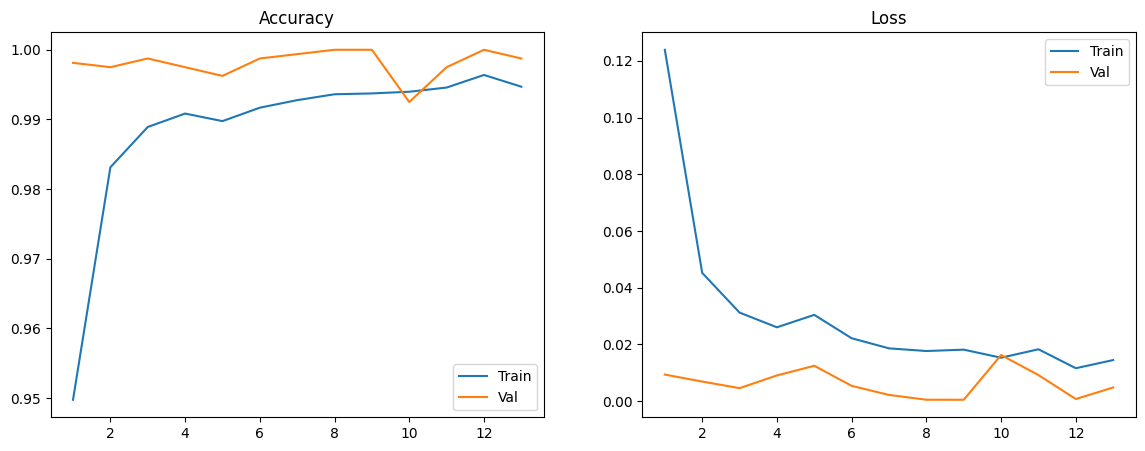

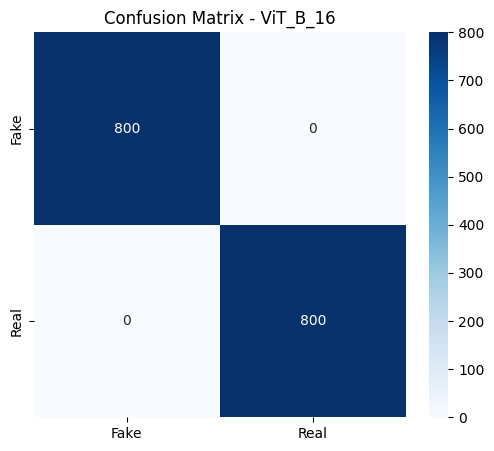

✅ ViT Config D (Low LR) - Done.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import time
import os
import copy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CONFIGURATION (ViT - CONFIG D - LOW LR) ---
RUN_NAME       = "Run_04_ConfigD_LR_Low"   # <--- CONFIG D
MODEL_ARCH     = "ViT_B_16"                # ViT
BATCH_SIZE     = 16                        # Back to 16
LEARNING_RATE  = 0.00001                   # <--- LOW LR (1e-5)
OPTIMIZER_NAME = "Adam"                    # Adam
NUM_EPOCHS     = 50
PATIENCE       = 5

SAVE_DIR = f"/content/drive/MyDrive/FYP_Project/Models/{MODEL_ARCH}/{RUN_NAME}"
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"📂 Saving results to: {SAVE_DIR}")

# --- 2. SETUP DATA & MODEL ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Starting {MODEL_ARCH} - {RUN_NAME} on {device}...")

# USING THE "NUCLEAR" AUGMENTATIONS
data_transforms = {
    'Train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(30),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.8, 1.2)),
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
        transforms.RandomGrayscale(p=0.1),
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 2.0)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'Val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/dataset/03_Mini_Dataset'

if os.path.exists(data_dir):
    image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['Train', 'Val']}
    dataloaders = {x: DataLoader(image_datasets[x], batch_size=BATCH_SIZE, shuffle=True, num_workers=2) for x in ['Train', 'Val']}
    dataset_sizes = {x: len(image_datasets[x]) for x in ['Train', 'Val']}
    print(f"📊 Dataset Stats: Train={dataset_sizes['Train']}, Val={dataset_sizes['Val']}")
else:
    print("❌ ERROR: Dataset not found.")
    exit()

# --- LOAD ViT ---
print(f"⏳ Loading {MODEL_ARCH} weights...")
model = models.vit_b_16(weights='DEFAULT')

# ViT Head Replacement
num_ftrs = model.heads.head.in_features
model.heads.head = nn.Linear(num_ftrs, 2)
model = model.to(device)

if OPTIMIZER_NAME == "Adam":
    print(f"⚙️ Using Adam (LR={LEARNING_RATE})")
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
elif OPTIMIZER_NAME == "SGD":
    optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=0.9)

criterion = nn.CrossEntropyLoss()

# --- 3. TRAINING LOOP ---
since = time.time()
best_model_wts = copy.deepcopy(model.state_dict())
best_acc = 0.0
early_stop_counter = 0
history = []

for epoch in range(NUM_EPOCHS):
    print(f'\nEpoch {epoch+1}/{NUM_EPOCHS}')
    print('-' * 10)
    epoch_stats = {'Epoch': epoch+1}

    for phase in ['Train', 'Val']:
        if phase == 'Train': model.train()
        else: model.eval()

        running_loss = 0.0
        running_corrects = 0
        all_labels = []
        all_preds = []
        all_probs_fake = []

        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'Train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                if phase == 'Train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

            if phase == 'Val':
                probs = torch.nn.functional.softmax(outputs, dim=1)
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(preds.cpu().numpy())
                all_probs_fake.extend(probs[:, 0].cpu().detach().numpy())

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

        epoch_stats[f'{phase}_Loss'] = epoch_loss
        epoch_stats[f'{phase}_Acc'] = epoch_acc.item()

        if phase == 'Val':
            binary_labels = [1 if x == 0 else 0 for x in all_labels]
            binary_preds  = [1 if x == 0 else 0 for x in all_preds]

            prec = precision_score(binary_labels, binary_preds, zero_division=0)
            rec  = recall_score(binary_labels, binary_preds, zero_division=0)
            f1   = f1_score(binary_labels, binary_preds, zero_division=0)
            try: auc = roc_auc_score(binary_labels, all_probs_fake)
            except: auc = 0.5
            tn, fp, fn, tp = confusion_matrix(binary_labels, binary_preds).ravel()
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

            print(f"   📊 Precision: {prec:.4f} | Recall: {rec:.4f} | Spec: {specificity:.4f} | AUC: {auc:.4f}")

            epoch_stats['Precision'] = prec
            epoch_stats['Recall'] = rec
            epoch_stats['Specificity'] = specificity
            epoch_stats['F1'] = f1
            epoch_stats['AUC'] = auc

            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                early_stop_counter = 0
            else:
                early_stop_counter += 1

    history.append(epoch_stats)
    if early_stop_counter >= PATIENCE:
        print(f"\n⏹️ Early stopping at epoch {epoch+1}")
        break

# Save & Plot
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_model.pth"))
pd.DataFrame(history).to_csv(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_metrics.csv"), index=False)

df = pd.DataFrame(history)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1); plt.plot(df['Epoch'], df['Train_Acc'], label='Train'); plt.plot(df['Epoch'], df['Val_Acc'], label='Val'); plt.title('Accuracy'); plt.legend()
plt.subplot(1, 2, 2); plt.plot(df['Epoch'], df['Train_Loss'], label='Train'); plt.plot(df['Epoch'], df['Val_Loss'], label='Val'); plt.title('Loss'); plt.legend()
plt.savefig(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_plots.png"))

# CM
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in dataloaders['Val']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title(f'Confusion Matrix - {MODEL_ARCH}')
plt.savefig(os.path.join(SAVE_DIR, f"{MODEL_ARCH}_{RUN_NAME}_conf_matrix.png"))
plt.show()

print("✅ ViT Config D (Low LR) - Done.")